In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_gen import generate_dataset

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.dpi": 100
})

In [2]:
#Fijamos semilla en 42 para reproducibilidad
np.random.seed(42) 
df = generate_dataset(A0=100.0, B0=150.0, save_to_csv=True)
display(df.head())

Dataset sintético generado y guardado en ../data/synthetic/ddi_synthetic_data.csv


,time,true_A,true_B,obs_A,obs_B
0,0.000000,100.000000,150.000000,107.516649,145.447263
1,0.100000,99.805825,147.090000,97.717498,160.837931
2,0.121621,99.763843,146.460837,109.542407,146.361079
3,0.147916,99.712784,145.695644,122.695369,137.918192
4,0.179896,99.649748,144.786950,96.118559,150.798181


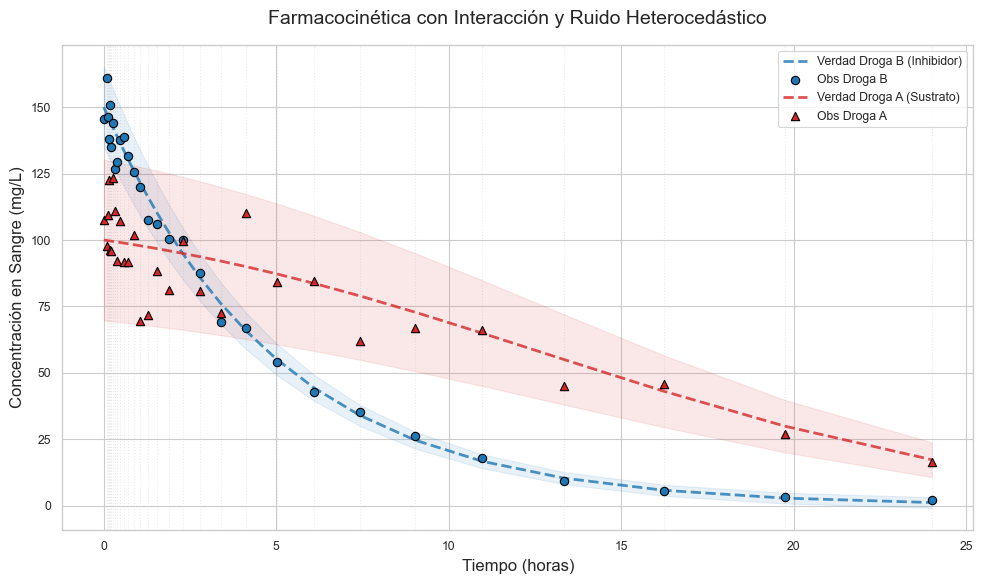

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

t = df['time'].values
true_A, true_B = df['true_A'].values, df['true_B'].values
obs_A, obs_B = df['obs_A'].values, df['obs_B'].values

#Parámetros de ruido que inyectamos en data_gen.py para reconstruir las bandas
sigma_add_A, sigma_prop_A = 2.0, 0.15
sigma_add_B, sigma_prop_B = 1.0, 0.05

#Calculamos las desviaciones estándar heterocedásticas en cada punto
std_A = np.sqrt(sigma_add_A**2 + (sigma_prop_A * true_A)**2)
std_B = np.sqrt(sigma_add_B**2 + (sigma_prop_B * true_B)**2)

#Droga B (Inhibidor) - Azul
color_B = '#1f77b4'
ax.plot(t, true_B, '--', color=color_B, label='Verdad Droga B (Inhibidor)', alpha=0.8)
ax.fill_between(t, true_B - 2*std_B, true_B + 2*std_B, color=color_B, alpha=0.1)
ax.scatter(t, obs_B, color=color_B, edgecolor='black', zorder=3, label='Obs Droga B')

#Droga A (Sustrato) - Rojo
color_A = '#d62728'
ax.plot(t, true_A, '--', color=color_A, label='Verdad Droga A (Sustrato)', alpha=0.8)
ax.fill_between(t, true_A - 2*std_A, true_A + 2*std_A, color=color_A, alpha=0.1)
ax.scatter(t, obs_A, marker='^', color=color_A, edgecolor='black', zorder=3, label='Obs Droga A')

ax.set_title("Farmacocinética con Interacción y Ruido Heterocedástico", pad=15)
ax.set_xlabel("Tiempo (horas)")
ax.set_ylabel("Concentración en Sangre (mg/L)")

ax.set_xticks(t, minor=True)
ax.grid(which='minor', axis='x', linestyle=':', alpha=0.4)

ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()